# Project 4: Credit Card Fraud Detection

This notebook uses the enriched `fraudTest_combined.csv` dataset.  
Two ZIP-level socioeconomic variables are added into the modeling framework:

- `median_household_income`
- `poverty_rate`

The main models are:

1. Logistic Regression
2. Decision Tree
3. XGBoost


## 1. Imports


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)

from sklearn.tree import DecisionTreeClassifier, plot_tree

# XGBoost
from xgboost import XGBClassifier

# Make plots display clearly
plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["axes.grid"] = True


## 2. Load Data and Drop Unused Columns


In [2]:
# Load the enriched dataset
Fraud = pd.read_csv("fraudTest_combined.csv")

print("Original data shape:", Fraud.shape)
print(Fraud.head())
print(Fraud.columns)


Original data shape: (555719, 25)
   Unnamed: 0 trans_date_trans_time            cc_num  \
0           0   2020-06-21 12:14:25  2291163933867244   
1           1   2020-06-21 12:14:33  3573030041201292   
2           2   2020-06-21 12:14:53  3598215285024754   
3           3   2020-06-21 12:15:15  3591919803438423   
4           4   2020-06-21 12:15:17  3526826139003047   

                               merchant        category    amt   first  \
0                 fraud_Kirlin and Sons   personal_care   2.86    Jeff   
1                  fraud_Sporer-Keebler   personal_care  29.84  Joanne   
2  fraud_Swaniawski, Nitzsche and Welch  health_fitness  41.28  Ashley   
3                     fraud_Haley Group        misc_pos  60.05   Brian   
4                 fraud_Johnston-Casper          travel   3.19  Nathan   

       last gender                       street  ... city_pop  \
0   Elliott      M            351 Darlene Green  ...   333497   
1  Williams      F             3638 Marsh Union 

In [3]:
# Drop variables that are not used directly in the modeling stage
drop_cols = [
    "Unnamed: 0",
    "cc_num",
    "merchant",
    "first",
    "last",
    "street",
    "city",
    "zip",
    "lat",
    "long",
    "job",
    "trans_num",
    "unix_time",
    "merch_lat",
    "merch_long"
]

Fraud = Fraud.drop(columns=drop_cols, errors="ignore")

print("Data shape after dropping unused columns:", Fraud.shape)
print(Fraud.columns)


Data shape after dropping unused columns: (555719, 10)
Index(['trans_date_trans_time', 'category', 'amt', 'gender', 'state',
       'city_pop', 'dob', 'is_fraud', 'median_household_income',
       'poverty_rate'],
      dtype='object')


## 3. Recode State into Region


In [4]:
state_to_region = {
    # Northeast
    "ME": "Northeast", "NH": "Northeast", "VT": "Northeast",
    "MA": "Northeast", "RI": "Northeast", "CT": "Northeast",
    "NY": "Northeast", "NJ": "Northeast", "PA": "Northeast",

    # Midwest
    "OH": "Midwest", "IN": "Midwest", "IL": "Midwest", "MI": "Midwest",
    "WI": "Midwest", "MN": "Midwest", "IA": "Midwest", "MO": "Midwest",
    "ND": "Midwest", "SD": "Midwest", "NE": "Midwest", "KS": "Midwest",

    # South
    "DE": "South", "MD": "South", "DC": "South", "VA": "South",
    "WV": "South", "NC": "South", "SC": "South", "GA": "South",
    "FL": "South", "KY": "South", "TN": "South", "MS": "South",
    "AL": "South", "OK": "South", "TX": "South", "AR": "South",
    "LA": "South",

    # West
    "MT": "West", "ID": "West", "WY": "West", "CO": "West",
    "NM": "West", "AZ": "West", "UT": "West", "NV": "West",
    "WA": "West", "OR": "West", "CA": "West", "AK": "West",
    "HI": "West"
}

Fraud["region"] = Fraud["state"].map(state_to_region)
Fraud = Fraud.drop(columns=["state"], errors="ignore")

print(Fraud["region"].value_counts(dropna=False))


region
South        211277
Midwest      156993
Northeast    104851
West          82598
Name: count, dtype: int64


## 4. Generate Age and Late-Night Indicator


In [5]:
Fraud["dob"] = pd.to_datetime(Fraud["dob"], errors="coerce")
Fraud["trans_date_trans_time"] = pd.to_datetime(Fraud["trans_date_trans_time"], errors="coerce")

# Age at transaction time
Fraud["age"] = (
    Fraud["trans_date_trans_time"].dt.year - Fraud["dob"].dt.year
    - (
        (Fraud["trans_date_trans_time"].dt.month < Fraud["dob"].dt.month) |
        (
            (Fraud["trans_date_trans_time"].dt.month == Fraud["dob"].dt.month) &
            (Fraud["trans_date_trans_time"].dt.day < Fraud["dob"].dt.day)
        )
    ).astype(int)
)

# Late night transactions: 22:00 to 03:59
Fraud["late_night"] = Fraud["trans_date_trans_time"].apply(
    lambda x: 1 if pd.notna(x) and (x.hour <= 3 or x.hour >= 22) else 0
)

Fraud[["dob", "trans_date_trans_time", "age", "late_night"]].head()


,dob,trans_date_trans_time,age,late_night
0,1968-03-19,2020-06-21 12:14:25,52,0
1,1990-01-17,2020-06-21 12:14:33,30,0
2,1970-10-21,2020-06-21 12:14:53,49,0
3,1987-07-25,2020-06-21 12:15:15,32,0
4,1955-07-06,2020-06-21 12:15:17,64,0


## 5. Filter Amount and Handle Missing Values


In [6]:
# Keep relatively large transactions, following the previous project design
Fraud = Fraud[Fraud["amt"] >= 600].copy()

print("Shape after keeping amt >= 600:", Fraud.shape)
print(Fraud["is_fraud"].value_counts())
print(Fraud["is_fraud"].value_counts(normalize=True))


Shape after keeping amt >= 600: (4166, 12)
is_fraud
0    3161
1    1005
Name: count, dtype: int64
is_fraud
0    0.758761
1    0.241239
Name: proportion, dtype: float64


In [7]:
# Drop date columns after generating age and late_night
Fraud = Fraud.drop(columns=["dob", "trans_date_trans_time"], errors="ignore")

# The two new ZIP-level socioeconomic variables may have missing values.
# Instead of dropping many rows, we use median imputation.
for col in ["median_household_income", "poverty_rate"]:
    if col in Fraud.columns:
        missing_before = Fraud[col].isna().sum()
        Fraud[col] = Fraud[col].fillna(Fraud[col].median())
        missing_after = Fraud[col].isna().sum()
        print(f"{col}: missing before = {missing_before}, missing after = {missing_after}")

# Drop any remaining missing values from other variables
Fraud_clean = Fraud.dropna().copy()

# Rescale amount and city population for easier interpretation
Fraud_clean["amt_thousand"] = Fraud_clean["amt"] / 1000
Fraud_clean["city_pop_thousand"] = Fraud_clean["city_pop"] / 1000

Fraud_clean = Fraud_clean.drop(columns=["amt", "city_pop"], errors="ignore")

print("Final clean data shape:", Fraud_clean.shape)
print(Fraud_clean.head())
print(Fraud_clean.columns)


median_household_income: missing before = 190, missing after = 0
poverty_rate: missing before = 57, missing after = 0
Final clean data shape: (4166, 10)
         category gender  is_fraud  median_household_income  poverty_rate  \
167  shopping_net      F         0                  54711.0          15.7   
428  shopping_pos      F         0                  37794.0           0.0   
600        travel      M         0                  58802.0           5.9   
720  shopping_net      F         0                  61726.0           5.2   
728  shopping_net      F         0                  56611.0          10.4   

        region  age  late_night  amt_thousand  city_pop_thousand  
167      South   37           0       1.19945            186.140  
428      South   31           0       1.88153              0.530  
600      South   36           0       0.61678              0.467  
720  Northeast   48           0       0.70559              1.368  
728      South   49           0       0.72414    

## 6. EDA: Target Distribution


          Count  Percentage
is_fraud                   
0          3161       75.88
1          1005       24.12


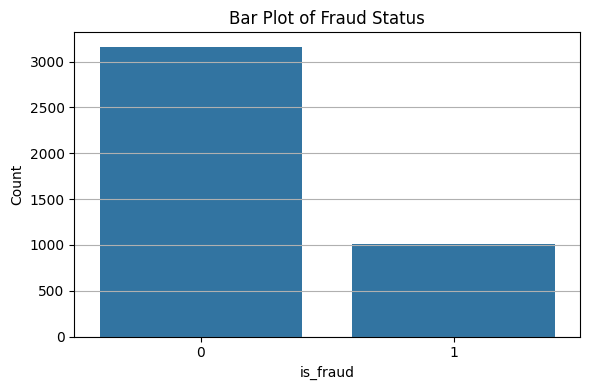

In [8]:
Fraud_clean["is_fraud"] = Fraud_clean["is_fraud"].astype(int)

fraud_counts = Fraud_clean["is_fraud"].value_counts().sort_index()
fraud_percent = Fraud_clean["is_fraud"].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    "Count": fraud_counts,
    "Percentage": fraud_percent.round(2)
})

print(target_summary)

plt.figure(figsize=(6, 4))
sns.countplot(data=Fraud_clean, x="is_fraud")
plt.title("Bar Plot of Fraud Status")
plt.xlabel("is_fraud")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


## 7. EDA: Numeric Variables by Fraud Group


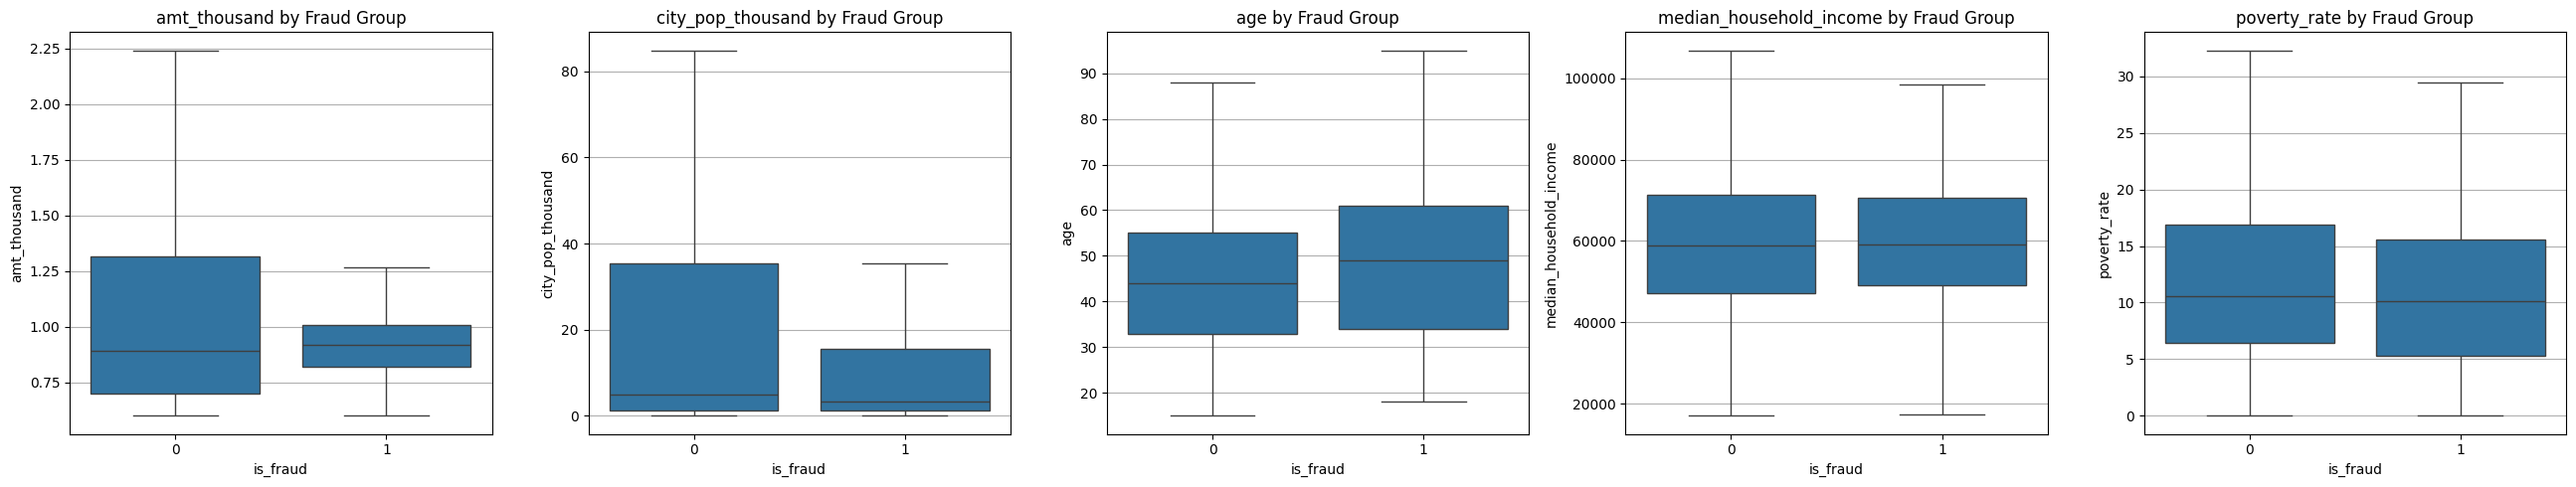

In [9]:
num_plot_vars = [
    "amt_thousand",
    "city_pop_thousand",
    "age",
    "median_household_income",
    "poverty_rate"
]

fig, axes = plt.subplots(1, len(num_plot_vars), figsize=(26, 5))

for i, var in enumerate(num_plot_vars):
    sns.boxplot(
        data=Fraud_clean,
        x="is_fraud",
        y=var,
        ax=axes[i],
        showfliers=False
    )
    axes[i].set_title(f"{var} by Fraud Group")
    axes[i].set_xlabel("is_fraud")
    axes[i].set_ylabel(var)

plt.tight_layout()
plt.show()


## 8. EDA: Contingency Tables


In [10]:
cat_vars = ["category", "gender", "region", "late_night"]

for var in cat_vars:
    print(f"\nContingency Table: {var} vs is_fraud")
    print(pd.crosstab(Fraud_clean[var], Fraud_clean["is_fraud"]))

    print(f"\nRow Percentage Table: {var} vs is_fraud")
    print(pd.crosstab(Fraud_clean[var], Fraud_clean["is_fraud"], normalize="index").round(3))



Contingency Table: category vs is_fraud
is_fraud          0    1
category                
entertainment    10    6
misc_net        405  264
misc_pos        405   17
shopping_net    896  506
shopping_pos   1118  212
travel          327    0

Row Percentage Table: category vs is_fraud
is_fraud           0      1
category                   
entertainment  0.625  0.375
misc_net       0.605  0.395
misc_pos       0.960  0.040
shopping_net   0.639  0.361
shopping_pos   0.841  0.159
travel         1.000  0.000

Contingency Table: gender vs is_fraud
is_fraud     0    1
gender             
F         1975  474
M         1186  531

Row Percentage Table: gender vs is_fraud
is_fraud      0      1
gender                
F         0.806  0.194
M         0.691  0.309

Contingency Table: region vs is_fraud
is_fraud      0    1
region              
Midwest     836  308
Northeast   560  213
South      1255  341
West        510  143

Row Percentage Table: region vs is_fraud
is_fraud       0      1
region 

## 9. EDA: Correlation Matrix


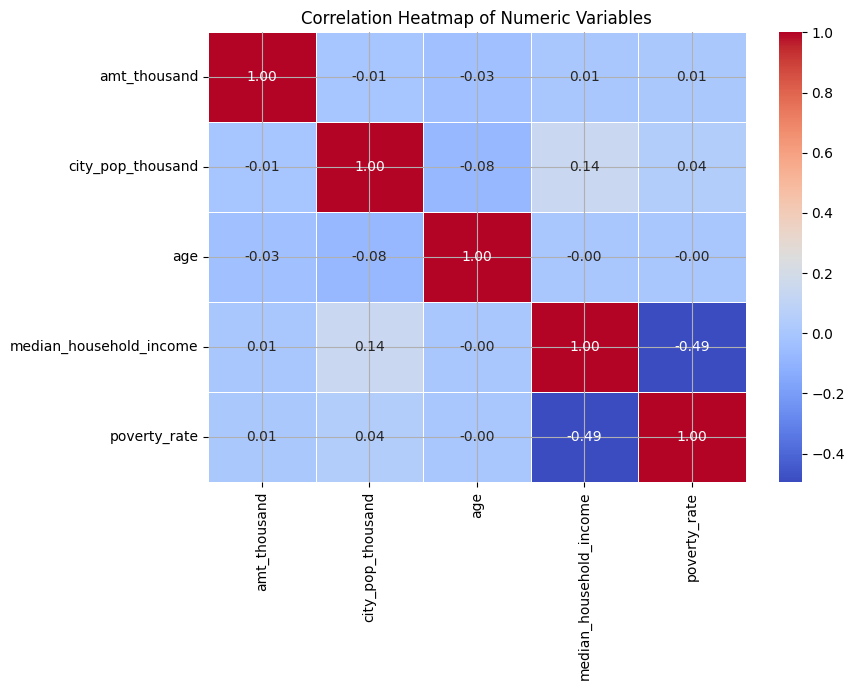

In [11]:
num_vars = [
    "amt_thousand",
    "city_pop_thousand",
    "age",
    "median_household_income",
    "poverty_rate"
]

corr_matrix = Fraud_clean[num_vars].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)
plt.title("Correlation Heatmap of Numeric Variables")
plt.tight_layout()
plt.show()


## 10. PCA Visualization


Explained variance ratio:
[0.12056656 0.1067883 ]
Total explained variance by PC1 and PC2:
0.22735485938032574


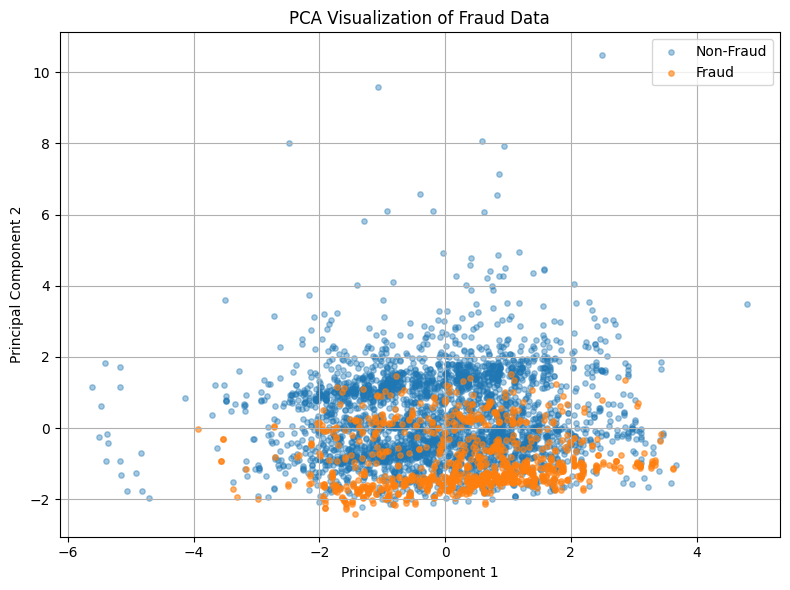

In [12]:
target_col = "is_fraud"

y_pca = Fraud_clean[target_col]
X_pca_raw = Fraud_clean.drop(columns=[target_col])

# One-hot encode categorical variables for PCA visualization
X_pca = pd.get_dummies(X_pca_raw, drop_first=True, dtype=int)

scaler_pca = StandardScaler()
X_scaled = scaler_pca.fit_transform(X_pca)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    data=pca_result,
    columns=["PC1", "PC2"]
)

pca_df["is_fraud"] = y_pca.values

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

print("Total explained variance by PC1 and PC2:")
print(pca.explained_variance_ratio_.sum())

plt.figure(figsize=(8, 6))

plt.scatter(
    pca_df.loc[pca_df["is_fraud"] == 0, "PC1"],
    pca_df.loc[pca_df["is_fraud"] == 0, "PC2"],
    alpha=0.4,
    label="Non-Fraud",
    s=15
)

plt.scatter(
    pca_df.loc[pca_df["is_fraud"] == 1, "PC1"],
    pca_df.loc[pca_df["is_fraud"] == 1, "PC2"],
    alpha=0.6,
    label="Fraud",
    s=15
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of Fraud Data")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## 11. One-Hot Encoding


In [13]:
Fraud_onehot = pd.get_dummies(
    Fraud_clean,
    columns=["category", "gender", "region"],
    drop_first=True,
    dtype=int
)

print(Fraud_onehot.head())
print(Fraud_onehot.columns)
print("One-hot data shape:", Fraud_onehot.shape)


     is_fraud  median_household_income  poverty_rate  age  late_night  \
167         0                  54711.0          15.7   37           0   
428         0                  37794.0           0.0   31           0   
600         0                  58802.0           5.9   36           0   
720         0                  61726.0           5.2   48           0   
728         0                  56611.0          10.4   49           0   

     amt_thousand  city_pop_thousand  category_misc_net  category_misc_pos  \
167       1.19945            186.140                  0                  0   
428       1.88153              0.530                  0                  0   
600       0.61678              0.467                  0                  0   
720       0.70559              1.368                  0                  0   
728       0.72414             46.563                  0                  0   

     category_shopping_net  category_shopping_pos  category_travel  gender_M  \
167         

## 12. Helper Function for Model Evaluation


In [14]:
def evaluate_binary_model(y_true, y_pred, y_prob, model_name):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    accuracy = accuracy_score(y_true, y_pred)
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    auc = roc_auc_score(y_true, y_prob)
    balanced_accuracy = (sensitivity + specificity) / 2

    print(f"{model_name} Confusion Matrix:")
    print(cm)
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Sensitivity / Recall: {sensitivity:.4f}")
    print(f"Specificity: {specificity:.4f}")
    print(f"Balanced Accuracy: {balanced_accuracy:.4f}")
    print(f"AUC: {auc:.4f}")

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Non-Fraud", "Fraud"]
    )
    disp.plot(values_format="d")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.grid(False)
    plt.tight_layout()
    plt.show()

    fpr, tpr, thresholds = roc_curve(y_true, y_prob)

    plt.figure(figsize=(7, 6))
    plt.plot(fpr, tpr, label=f"{model_name} AUC = {auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {model_name}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "Balanced Accuracy": balanced_accuracy,
        "AUC": auc
    }


## 13. Logistic Regression


         Current function value: 0.339314
         Iterations: 200
                           Logit Regression Results                           
Dep. Variable:               is_fraud   No. Observations:                 3332
Model:                          Logit   Df Residuals:                     3316
Method:                           MLE   Df Model:                           15
Date:                Mon, 27 Apr 2026   Pseudo R-squ.:                  0.3859
Time:                        21:02:20   Log-Likelihood:                -1130.6
converged:                      False   LL-Null:                       -1841.2
Covariance Type:            nonrobust   LLR p-value:                4.695e-294
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                      -1.7245      0.703     -2.453      0.014      -3.102      -0.347
median_household_income  

d:\apps\Anaconda\install\envs\pytorch\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


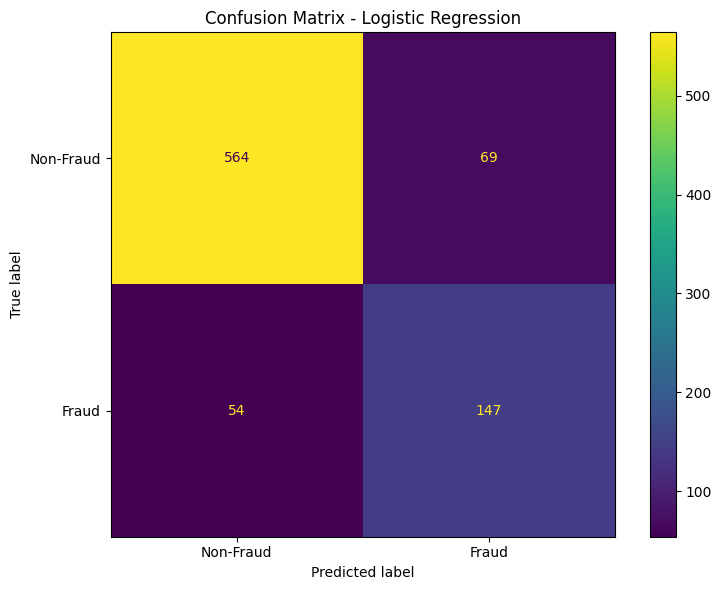

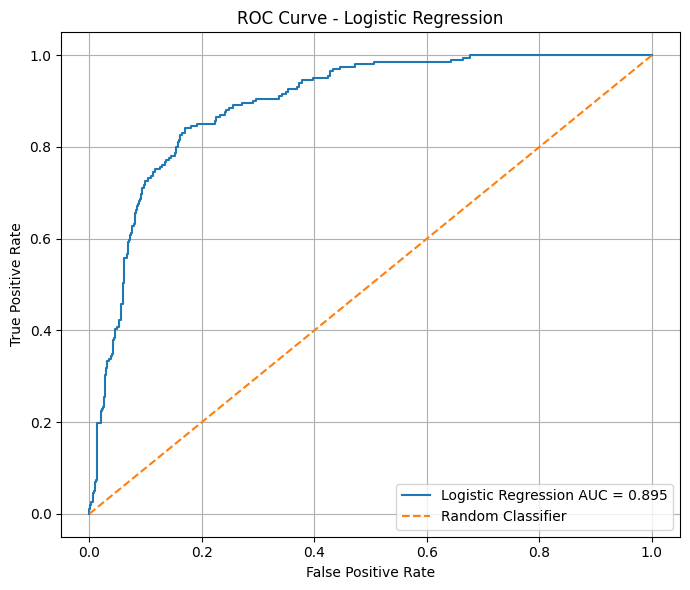

In [15]:
# Define X and y
X_logit = Fraud_onehot.drop(columns=["is_fraud"])
y_logit = Fraud_onehot["is_fraud"]

# Train-test split
X_train_logit, X_test_logit, y_train_logit, y_test_logit = train_test_split(
    X_logit,
    y_logit,
    test_size=0.2,
    random_state=42,
    stratify=y_logit
)

# Standardize numerical variables for Logistic Regression
numeric_cols = [
    "age",
    "late_night",
    "amt_thousand",
    "city_pop_thousand",
    "median_household_income",
    "poverty_rate"
]

scaler_logit = StandardScaler()

X_train_logit_scaled = X_train_logit.copy()
X_test_logit_scaled = X_test_logit.copy()

X_train_logit_scaled[numeric_cols] = scaler_logit.fit_transform(
    X_train_logit[numeric_cols]
)

X_test_logit_scaled[numeric_cols] = scaler_logit.transform(
    X_test_logit[numeric_cols]
)

# Add constant for statsmodels
X_train_logit_scaled = sm.add_constant(X_train_logit_scaled)
X_test_logit_scaled = sm.add_constant(X_test_logit_scaled)

# Fit Logistic Regression
logit_model = sm.Logit(y_train_logit, X_train_logit_scaled).fit(maxiter=200)
print(logit_model.summary())

# Predict
y_prob_logit = logit_model.predict(X_test_logit_scaled)
y_pred_logit = (y_prob_logit >= 0.5).astype(int)

logit_result = evaluate_binary_model(
    y_true=y_test_logit,
    y_pred=y_pred_logit,
    y_prob=y_prob_logit,
    model_name="Logistic Regression"
)

logit_accuracy = logit_result["Accuracy"]
logit_sensitivity = logit_result["Sensitivity"]
logit_specificity = logit_result["Specificity"]
logit_balanced_accuracy = logit_result["Balanced Accuracy"]
logit_auc = logit_result["AUC"]


## 14. Decision Tree


Decision Tree Confusion Matrix:
[[521 112]
 [ 17 184]]
Accuracy: 0.8453
Sensitivity / Recall: 0.9154
Specificity: 0.8231
Balanced Accuracy: 0.8692
AUC: 0.9077


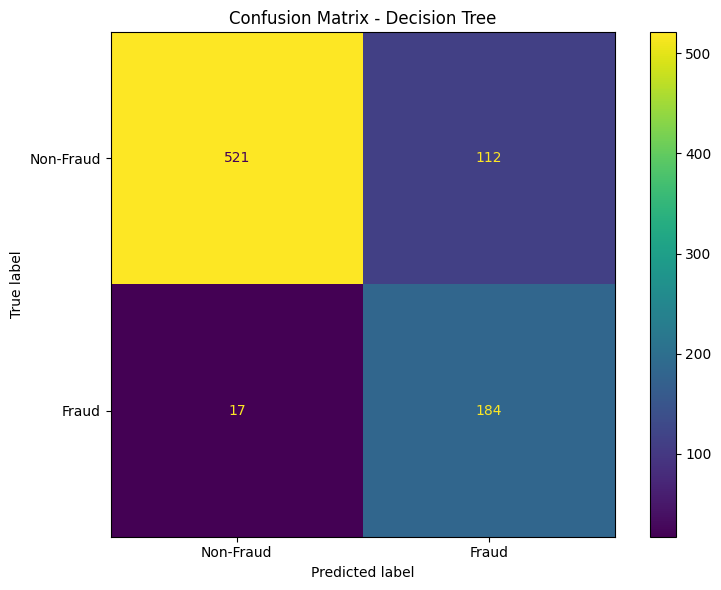

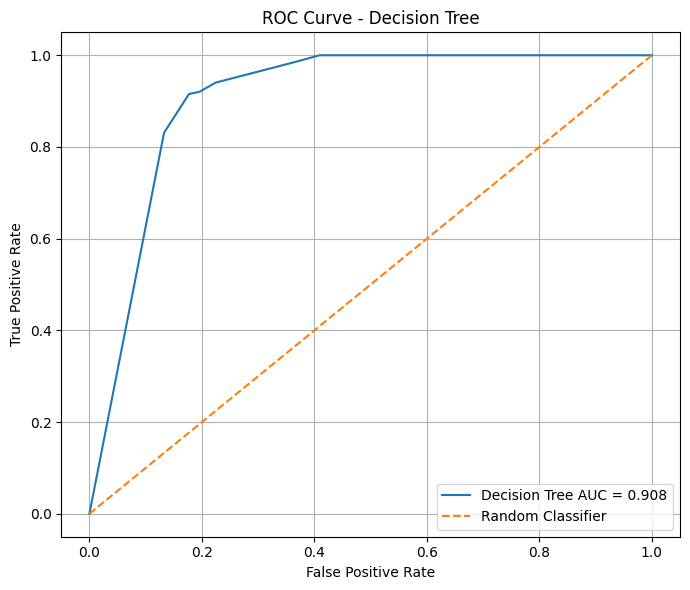

In [16]:
selected_cols = [
    "age",
    "late_night",
    "amt_thousand",
    "city_pop_thousand",
    "median_household_income",
    "poverty_rate"
] + [col for col in Fraud_onehot.columns if col.startswith("gender_")
] + [col for col in Fraud_onehot.columns if col.startswith("region_")
] + [col for col in Fraud_onehot.columns if col.startswith("category_")]

X_tree = Fraud_onehot[selected_cols]
y_tree = Fraud_onehot["is_fraud"]

X_train_tree, X_test_tree, y_train_tree, y_test_tree = train_test_split(
    X_tree,
    y_tree,
    test_size=0.2,
    random_state=42,
    stratify=y_tree
)

tree_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=4,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight="balanced"
)

tree_model.fit(X_train_tree, y_train_tree)

y_pred_tree = tree_model.predict(X_test_tree)
y_prob_tree = tree_model.predict_proba(X_test_tree)[:, 1]

tree_result = evaluate_binary_model(
    y_true=y_test_tree,
    y_pred=y_pred_tree,
    y_prob=y_prob_tree,
    model_name="Decision Tree"
)

tree_accuracy = tree_result["Accuracy"]
tree_sensitivity = tree_result["Sensitivity"]
tree_specificity = tree_result["Specificity"]
tree_balanced_accuracy = tree_result["Balanced Accuracy"]
tree_auc = tree_result["AUC"]


### Decision Tree Structure


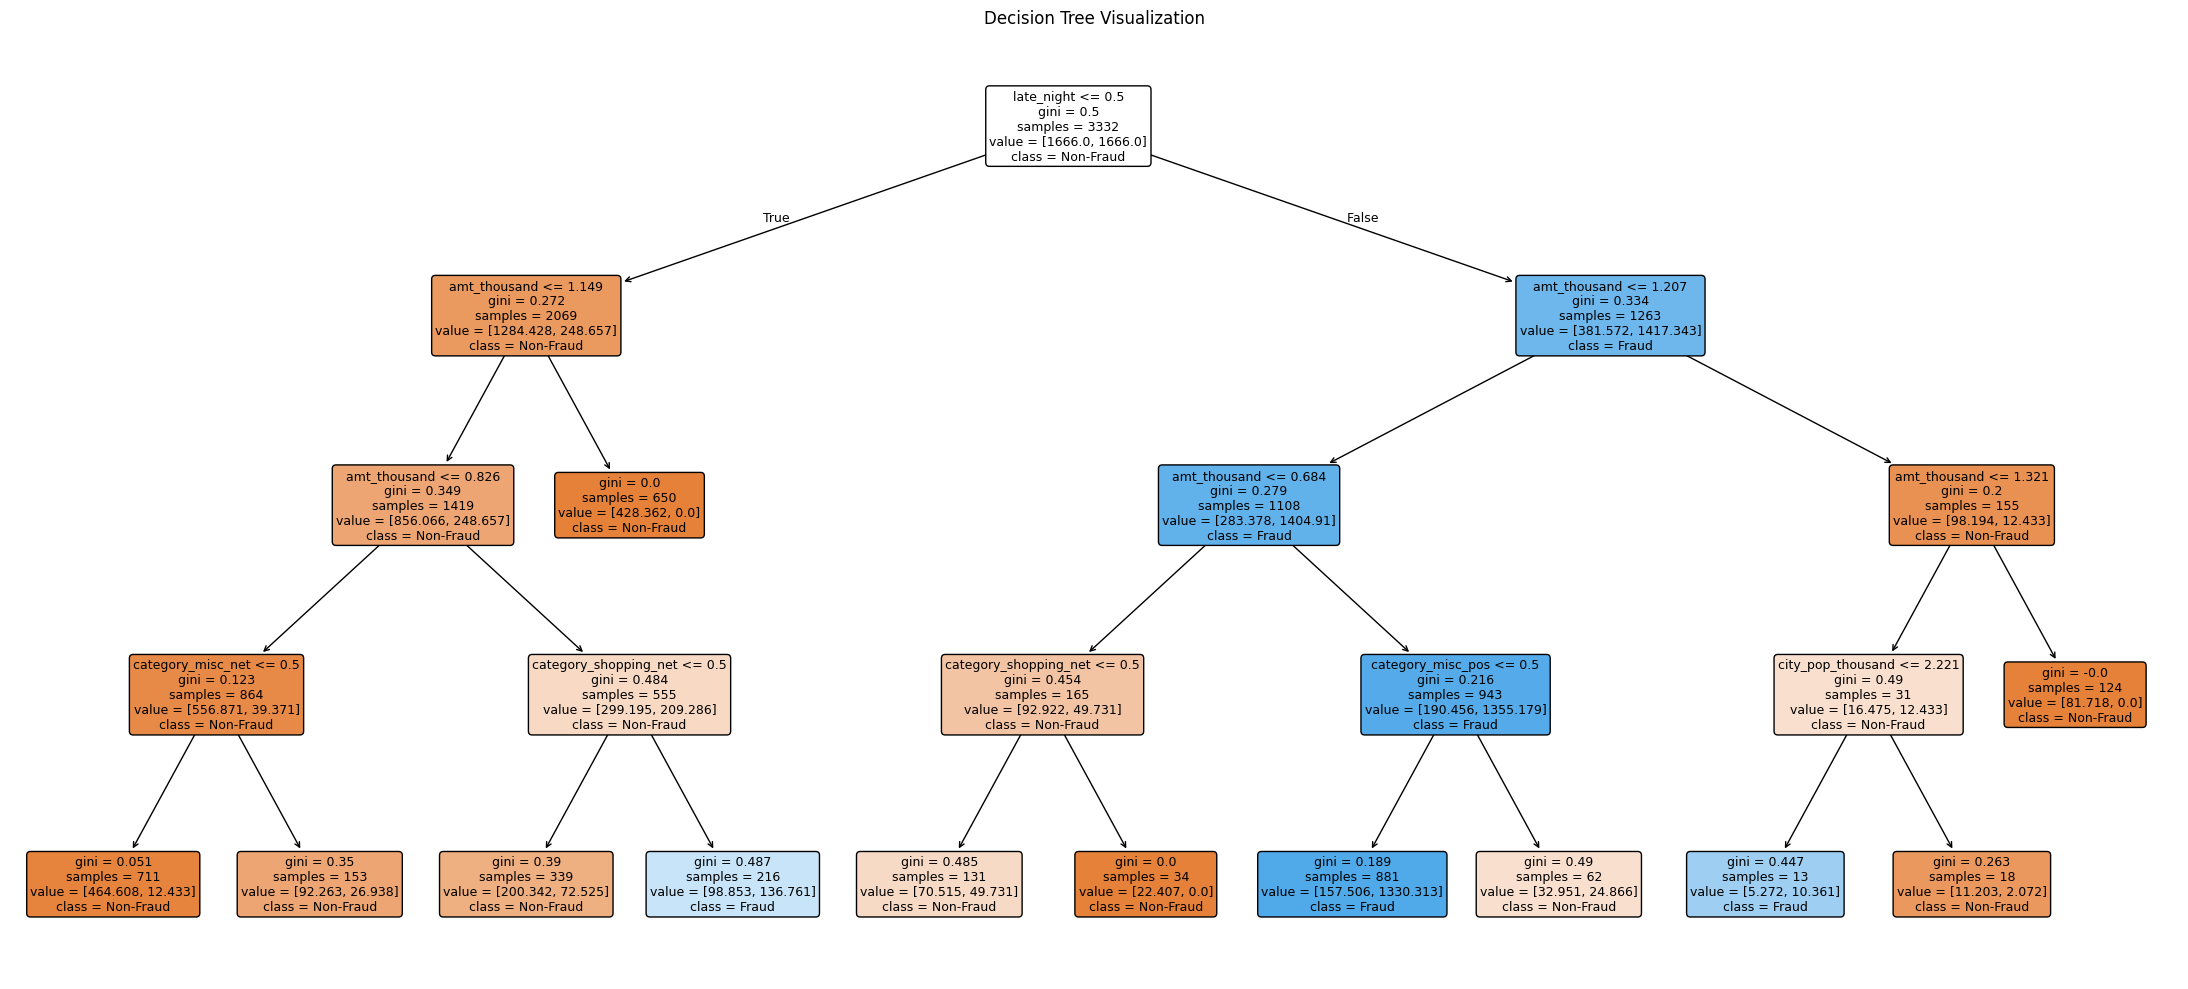

In [17]:
plt.figure(figsize=(22, 10))
plot_tree(
    tree_model,
    feature_names=X_tree.columns,
    class_names=["Non-Fraud", "Fraud"],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Decision Tree Visualization")
plt.tight_layout()
plt.show()


### Decision Tree Feature Importance


                    Feature  Importance
1                late_night    0.648070
2              amt_thousand    0.285152
12    category_shopping_net    0.031498
11        category_misc_pos    0.023970
10        category_misc_net    0.007624
3         city_pop_thousand    0.003686
0                       age    0.000000
6                  gender_M    0.000000
5              poverty_rate    0.000000
4   median_household_income    0.000000
7          region_Northeast    0.000000
9               region_West    0.000000
8              region_South    0.000000
13    category_shopping_pos    0.000000
14          category_travel    0.000000
            Variable_Group  Importance
5               late_night    0.648070
1             amt_thousand    0.285152
2                 category    0.063092
3        city_pop_thousand    0.003686
0                      age    0.000000
4                   gender    0.000000
6  median_household_income    0.000000
7             poverty_rate    0.000000
8        

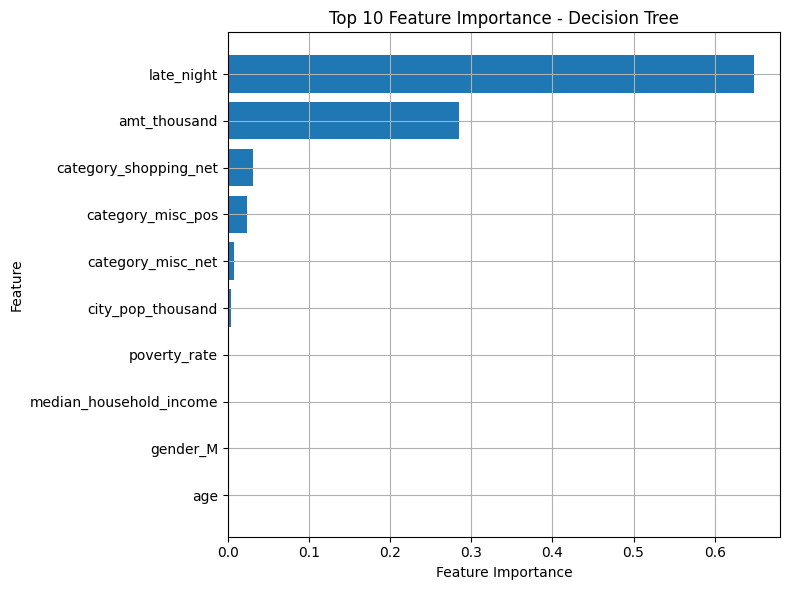

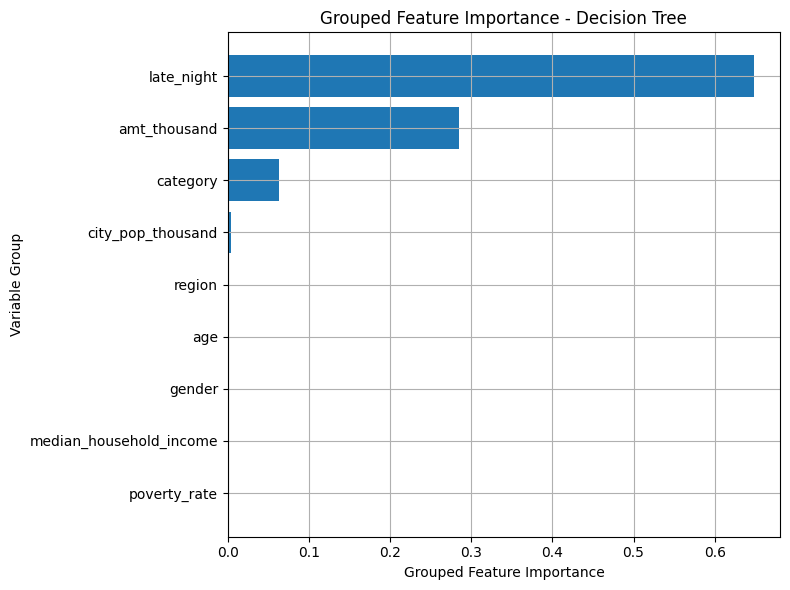

In [18]:
importance_df_tree = pd.DataFrame({
    "Feature": X_tree.columns,
    "Importance": tree_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importance_df_tree)

def get_feature_group(feature):
    categorical_groups = ["category", "gender", "region"]
    for cat in categorical_groups:
        if feature.startswith(cat + "_"):
            return cat
    return feature

importance_df_tree["Variable_Group"] = importance_df_tree["Feature"].apply(get_feature_group)

group_importance_tree = (
    importance_df_tree
    .groupby("Variable_Group", as_index=False)["Importance"]
    .sum()
    .sort_values(by="Importance", ascending=False)
)

print(group_importance_tree)

top10_tree = importance_df_tree.head(10).sort_values(by="Importance")

plt.figure(figsize=(8, 6))
plt.barh(top10_tree["Feature"], top10_tree["Importance"])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importance - Decision Tree")
plt.tight_layout()
plt.show()

plot_df_tree = group_importance_tree.sort_values("Importance")

plt.figure(figsize=(8, 6))
plt.barh(plot_df_tree["Variable_Group"], plot_df_tree["Importance"])
plt.xlabel("Grouped Feature Importance")
plt.ylabel("Variable Group")
plt.title("Grouped Feature Importance - Decision Tree")
plt.tight_layout()
plt.show()


## 15. XGBoost


scale_pos_weight: 3.144278606965174
XGBoost Confusion Matrix:
[[552  81]
 [ 11 190]]
Accuracy: 0.8897
Sensitivity / Recall: 0.9453
Specificity: 0.8720
Balanced Accuracy: 0.9087
AUC: 0.9691


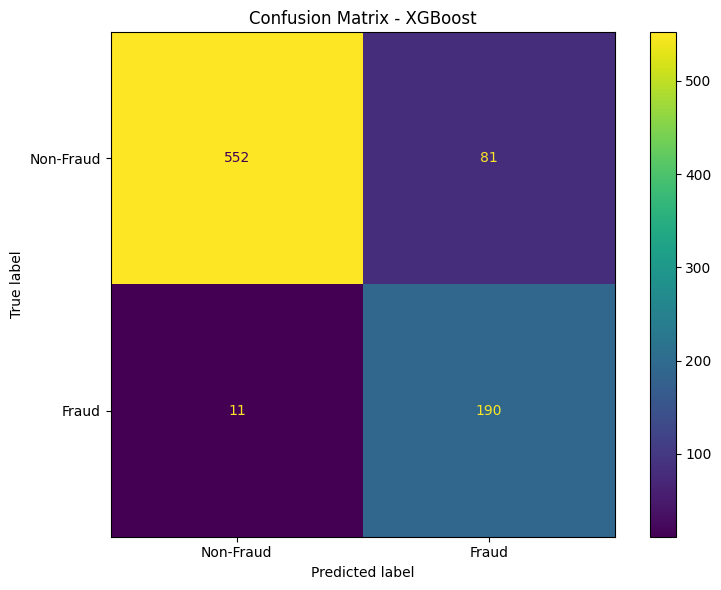

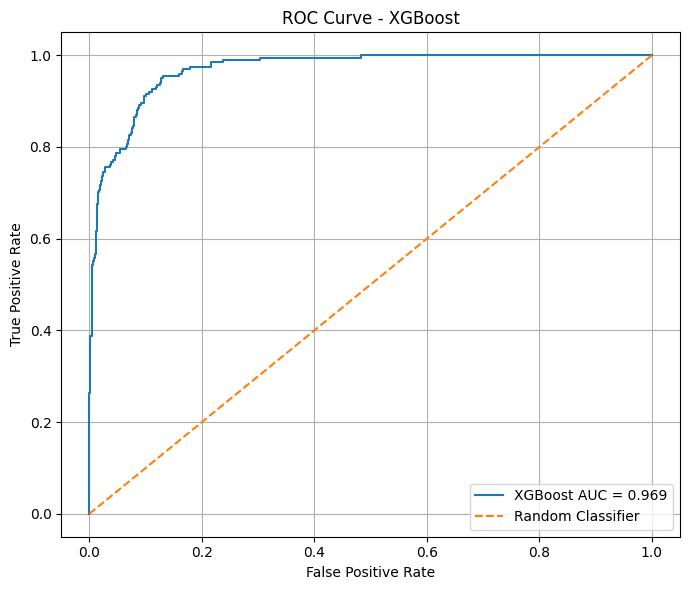

In [19]:
X_xgb = Fraud_onehot[selected_cols]
y_xgb = Fraud_onehot["is_fraud"]

X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(
    X_xgb,
    y_xgb,
    test_size=0.2,
    random_state=42,
    stratify=y_xgb
)

# Handle moderate class imbalance
scale_pos_weight = (y_train_xgb == 0).sum() / (y_train_xgb == 1).sum()
print("scale_pos_weight:", scale_pos_weight)

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_train_xgb, y_train_xgb)

y_pred_xgb = xgb_model.predict(X_test_xgb)
y_prob_xgb = xgb_model.predict_proba(X_test_xgb)[:, 1]

xgb_result = evaluate_binary_model(
    y_true=y_test_xgb,
    y_pred=y_pred_xgb,
    y_prob=y_prob_xgb,
    model_name="XGBoost"
)

xgb_accuracy = xgb_result["Accuracy"]
xgb_sensitivity = xgb_result["Sensitivity"]
xgb_specificity = xgb_result["Specificity"]
xgb_balanced_accuracy = xgb_result["Balanced Accuracy"]
xgb_auc = xgb_result["AUC"]


### XGBoost Feature Importance


                    Feature  Importance
1                late_night    0.538774
2              amt_thousand    0.080900
11        category_misc_pos    0.052150
12    category_shopping_net    0.049950
10        category_misc_net    0.048902
14          category_travel    0.041541
6                  gender_M    0.028397
13    category_shopping_pos    0.027556
3         city_pop_thousand    0.023273
0                       age    0.023007
5              poverty_rate    0.020873
4   median_household_income    0.019448
9               region_West    0.016388
7          region_Northeast    0.014471
8              region_South    0.014370
                     Group  Importance
5               late_night    0.538774
2                 category    0.220099
1             amt_thousand    0.080900
8                   region    0.045230
4                   gender    0.028397
3        city_pop_thousand    0.023273
0                      age    0.023007
7             poverty_rate    0.020873
6  median

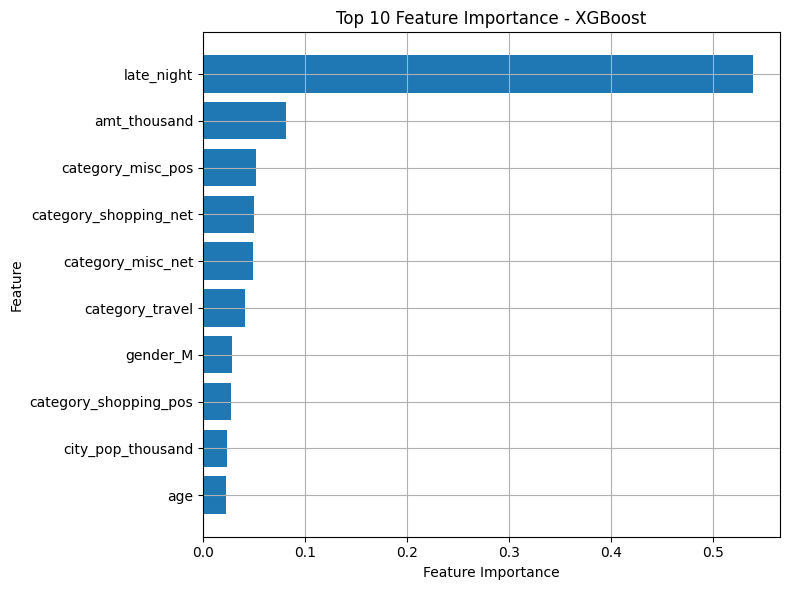

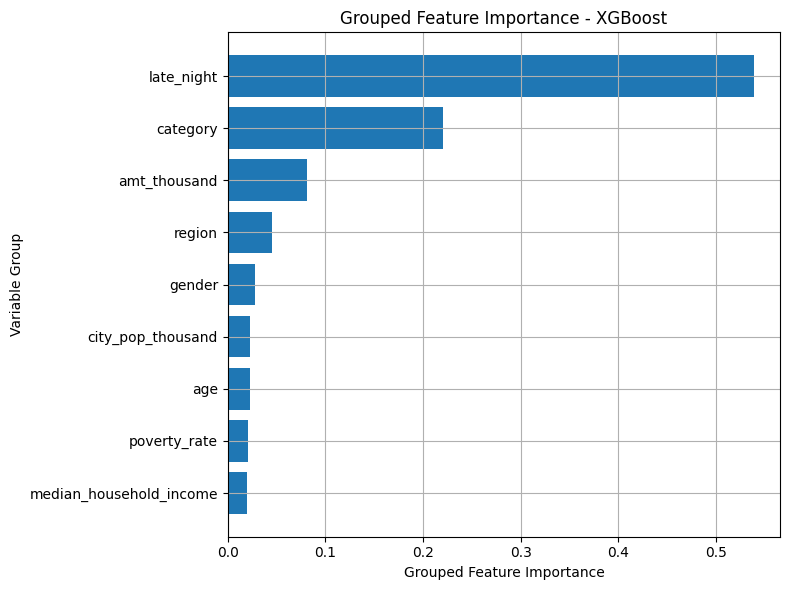

In [20]:
importance_df_xgb = pd.DataFrame({
    "Feature": X_xgb.columns,
    "Importance": xgb_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importance_df_xgb)

importance_df_xgb["Group"] = importance_df_xgb["Feature"].apply(get_feature_group)

group_importance_xgb = (
    importance_df_xgb
    .groupby("Group", as_index=False)["Importance"]
    .sum()
    .sort_values(by="Importance", ascending=False)
)

print(group_importance_xgb)

top10_xgb = importance_df_xgb.head(10).sort_values(by="Importance")

plt.figure(figsize=(8, 6))
plt.barh(top10_xgb["Feature"], top10_xgb["Importance"])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importance - XGBoost")
plt.tight_layout()
plt.show()

plot_df_xgb = group_importance_xgb.sort_values("Importance")

plt.figure(figsize=(8, 6))
plt.barh(plot_df_xgb["Group"], plot_df_xgb["Importance"])
plt.xlabel("Grouped Feature Importance")
plt.ylabel("Variable Group")
plt.title("Grouped Feature Importance - XGBoost")
plt.tight_layout()
plt.show()


## 16. Model Comparison


                 Model  Accuracy  Sensitivity  Specificity  Balanced Accuracy  \
0  Logistic Regression  0.852518     0.731343     0.890995           0.811169   
1        Decision Tree  0.845324     0.915423     0.823065           0.869244   
2              XGBoost  0.889688     0.945274     0.872038           0.908656   

        AUC  
0  0.895035  
1  0.907701  
2  0.969104  


<Figure size 1000x600 with 0 Axes>

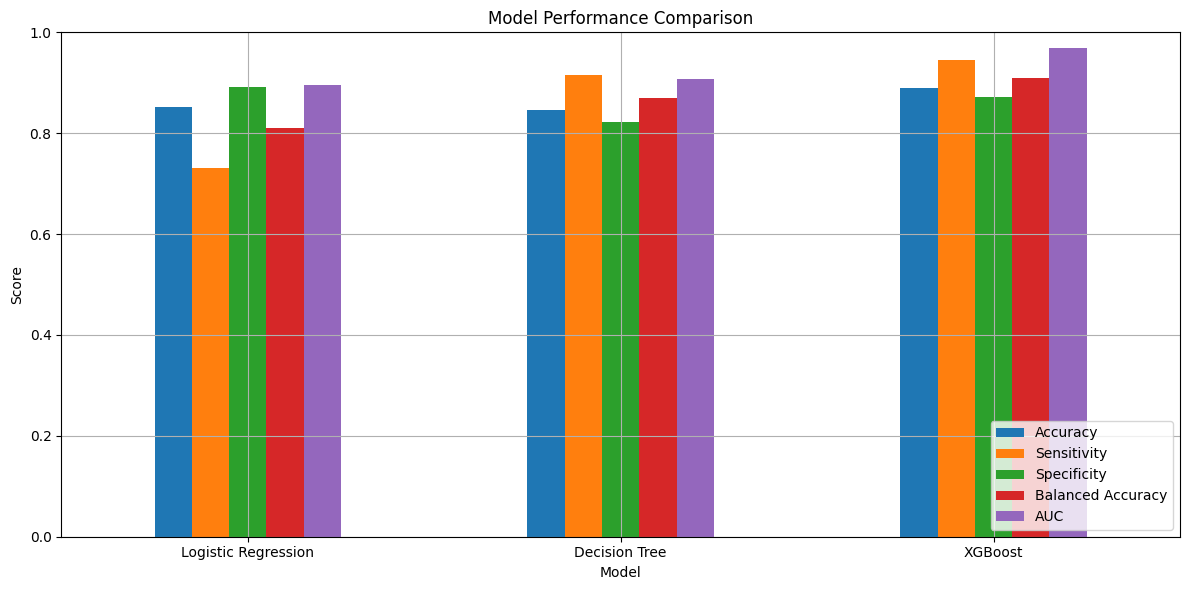

In [21]:
results = pd.DataFrame([
    logit_result,
    tree_result,
    xgb_result
])

# Reorder columns
results = results[
    ["Model", "Accuracy", "Sensitivity", "Specificity", "Balanced Accuracy", "AUC"]
]

print(results)

# Bar plot of model comparison
results_plot = results.set_index("Model")

plt.figure(figsize=(10, 6))
results_plot[["Accuracy", "Sensitivity", "Specificity", "Balanced Accuracy", "AUC"]].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


## 17. Combined ROC Curve


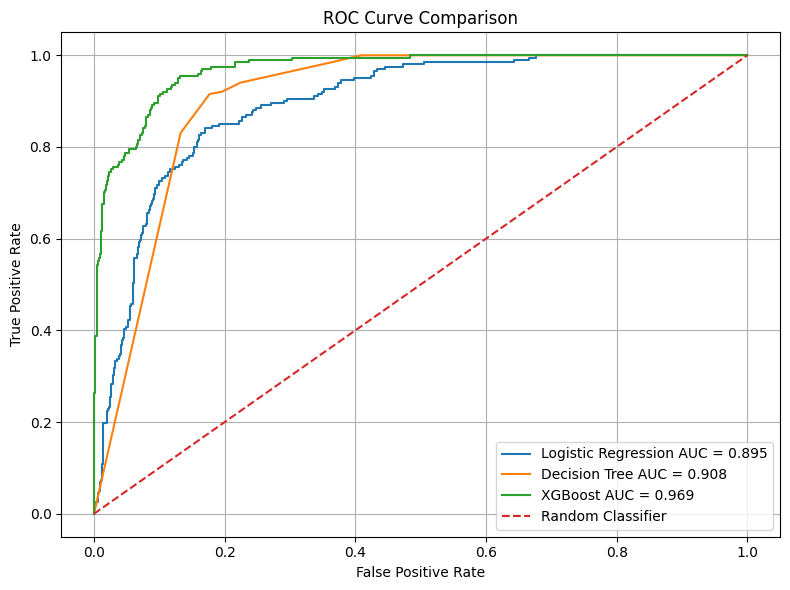

In [22]:
fpr_logit, tpr_logit, _ = roc_curve(y_test_logit, y_prob_logit)
fpr_tree, tpr_tree, _ = roc_curve(y_test_tree, y_prob_tree)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test_xgb, y_prob_xgb)

plt.figure(figsize=(8, 6))

plt.plot(fpr_logit, tpr_logit, label=f"Logistic Regression AUC = {logit_auc:.3f}")
plt.plot(fpr_tree, tpr_tree, label=f"Decision Tree AUC = {tree_auc:.3f}")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost AUC = {xgb_auc:.3f}")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Notes for Presentation

After adding ZIP-level socioeconomic variables, `median_household_income` and `poverty_rate` were incorporated into the modeling framework.  
Missing values in these external variables were imputed using median values.  
For Logistic Regression, numerical predictors were standardized to address scale differences across variables.  
For tree-based models, the socioeconomic variables were directly included as additional predictors.  
Because the dataset is moderately imbalanced, Decision Tree uses `class_weight="balanced"` and XGBoost uses `scale_pos_weight`.
